<a href="https://colab.research.google.com/github/Sujiwankit/HW4-DADS6003/blob/main/Sujiwan_Kitsutum_ID6810422019_HW4_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HW4: Workshop
คำสั่ง
Using the provided dataset (train.csv and test.csv) on credit score ratings, create a Google Colab notebook to develop your best classification model. You must use only Logistic Regression and/or Naive Bayes to classify customers' credit scores from 'train.csv' into three categories: 'Standard,' 'Good,' and 'Poor' (within the 'Credit_Score' column). Your model will be evaluated using the F1 score.

Please submit a shareable link to your notebook, along with a 'result.csv' file. This file should contain the original 'test.csv' data with your predicted classifications added to the 'Credit_Score' column.

โดย สุจิวรรณ กิจสุธรรม ID 6810422019

# Credit Score Classification using Logistic Regression and Hybrid Customer-Based Strategy

โปรเจกต์นี้มีวัตถุประสงค์เพื่อจำแนกระดับเครดิตของลูกค้าออกเป็น 3 กลุ่ม ได้แก่ Good, Poor และ Standard โดยใช้ข้อมูลจาก `train.csv` สำหรับฝึกโมเดล และสร้างผลการทำนายใน `test.csv` เพื่อนำไปบันทึกเป็นไฟล์ `result.csv`

แนวทางของงานเป็นการผสมผสานระหว่าง Machine Learning และ rule-based hybrid strategy เพื่อใช้ประโยชน์จากข้อมูลประวัติลูกค้า (`Customer_ID`) ร่วมกับโมเดล Logistic Regression

ขั้นตอนหลักของการทำงานประกอบด้วย:

- Data loading  
- Data cleaning และ preprocessing  
- Feature engineering  
- Customer-level feature creation  
- Row signature และ lookup table construction  
- Logistic Regression modeling (พร้อม cross-validation)  
- Hold-out test evaluation (F1-score และ confusion matrix)  
- Hybrid prediction strategy  
- Result export (`result.csv`)

INSTALL / IMPORTS

In [ ]:
import os
import re
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Data Source

งานนี้ใช้ข้อมูล 2 ชุด ได้แก่

- `train.csv` สำหรับฝึกโมเดล
- `test.csv` สำหรับสร้างผลทำนายสุดท้าย

ในขั้นตอนนี้จะอัปโหลดไฟล์เข้าสู่ Colab และตรวจสอบขนาดข้อมูล พร้อมดูการกระจายของ target variable คือ `Credit_Score`

In [ ]:
uploaded = files.upload()

def find_csv(possible_names):
    for name in possible_names:
        if os.path.exists(name):
            return name
    return None

train_file = find_csv(["train.csv", "train (1).csv", "train(1).csv"])
test_file  = find_csv(["test.csv", "test (1).csv", "test(1).csv"])

if train_file is None or test_file is None:
    raise FileNotFoundError("หาไฟล์ train.csv หรือ test.csv ไม่เจอ กรุณาอัปโหลดใหม่")

train_raw = pd.read_csv(train_file)
test_raw  = pd.read_csv(test_file)

print(f"Train shape: {train_raw.shape}")
print(f"Test shape : {test_raw.shape}")

print("\nTrain Credit_Score distribution:")
print(train_raw["Credit_Score"].value_counts())

Saving test.csv to test.csv
Saving train.csv to train.csv
Train shape: (80000, 28)
Test shape : (20000, 28)

Train Credit_Score distribution:
Credit_Score
Standard    42537
Poor        23141
Good        14322
Name: count, dtype: int64


## 2. Data Cleaning

ข้อมูลดิบมีหลายคอลัมน์ที่ควรเป็นตัวเลข แต่ถูกเก็บในรูปแบบ string หรือมีอักขระปะปนอยู่ จึงต้องทำความสะอาดก่อนใช้งาน

ขั้นตอนนี้ประกอบด้วย:
- ทำความสะอาดคอลัมน์เชิงตัวเลข
- แปลง `Credit_History_Age` ให้อยู่ในหน่วยเดือน
- แปลงชื่อเดือนใน `Month` เป็นเลขเดือน
- จัดการค่าผิดรูปแบบในตัวแปร categorical บางตัว

In [ ]:
MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

DIRTY_NUM_COLS = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

def clean_numeric(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"[^0-9\.\-]", "", x)
    if x in ["", ".", "-", "-.", ".-"]:
        return np.nan
    try:
        return float(x)
    except:
        return np.nan

def clean_credit_history_age(x):
    if pd.isna(x):
        return np.nan
    nums = re.findall(r"\d+", str(x))
    if len(nums) >= 2:
        years = int(nums[0])
        months = int(nums[1])
        return years * 12 + months
    elif len(nums) == 1:
        return int(nums[0]) * 12
    return np.nan

def basic_clean(df):
    df = df.copy()

    for col in DIRTY_NUM_COLS:
        if col in df.columns:
            df[col] = df[col].apply(clean_numeric)

    if "Credit_History_Age" in df.columns:
        df["Credit_History_Age"] = df["Credit_History_Age"].apply(clean_credit_history_age)

    if "Month" in df.columns:
        df["Month_num"] = df["Month"].map(MONTH_MAP)

    if "Payment_of_Min_Amount" in df.columns:
        df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace({"NM": np.nan})

    if "Credit_Mix" in df.columns:
        df["Credit_Mix"] = df["Credit_Mix"].replace({"_": np.nan})

    return df

train = basic_clean(train_raw)
test = basic_clean(test_raw)

print("Cleaning done ✓")

Cleaning done ✓


## 3. Feature Engineering

หลังจากทำความสะอาดข้อมูลแล้ว มีการสร้างตัวแปรใหม่เพื่อสะท้อนพฤติกรรมทางการเงินของลูกค้า เช่น

- debt-to-income ratio
- EMI-to-salary ratio
- invest-to-salary ratio
- balance-to-salary ratio
- delay-per-loan
- inquiries-per-card
- interaction between credit limit change and credit utilization

รวมถึงการแปลงตัวแปร categorical บางตัวให้อยู่ในรูป ordinal

In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
def add_features(df):
    df = df.copy()
    eps = 1e-6

    if {"Outstanding_Debt", "Annual_Income"}.issubset(df.columns):
        df["debt_to_income"] = df["Outstanding_Debt"] / (df["Annual_Income"] + eps)

    if {"Total_EMI_per_month", "Monthly_Inhand_Salary"}.issubset(df.columns):
        df["emi_to_salary"] = df["Total_EMI_per_month"] / (df["Monthly_Inhand_Salary"] + eps)

    if {"Amount_invested_monthly", "Monthly_Inhand_Salary"}.issubset(df.columns):
        df["invest_to_salary"] = df["Amount_invested_monthly"] / (df["Monthly_Inhand_Salary"] + eps)

    if {"Monthly_Balance", "Monthly_Inhand_Salary"}.issubset(df.columns):
        df["balance_to_salary"] = df["Monthly_Balance"] / (df["Monthly_Inhand_Salary"] + eps)

    if {"Num_of_Delayed_Payment", "Num_of_Loan"}.issubset(df.columns):
        df["delay_per_loan"] = df["Num_of_Delayed_Payment"] / (df["Num_of_Loan"] + 1)

    if {"Num_Credit_Inquiries", "Num_Credit_Card"}.issubset(df.columns):
        df["inq_per_card"] = df["Num_Credit_Inquiries"] / (df["Num_Credit_Card"] + 1)

    if {"Changed_Credit_Limit", "Credit_Utilization_Ratio"}.issubset(df.columns):
        df["limit_util_interact"] = df["Changed_Credit_Limit"] * df["Credit_Utilization_Ratio"]

    if "Credit_Mix" in df.columns:
        df["Credit_Mix_ord"] = df["Credit_Mix"].map({
            "Bad": 0, "Standard": 1, "Good": 2
        })

    if "Payment_of_Min_Amount" in df.columns:
        df["Payment_Min_ord"] = df["Payment_of_Min_Amount"].map({
            "No": 0, "Yes": 1
        })

    return df

train = add_features(train)
test = add_features(test)

print("Feature engineering done ✓")

Feature engineering done ✓


## 4. Row Signature and Customer-Level Features

ในส่วนนี้มีการสร้าง:
- `row_signature` เพื่อจับ pattern ของแถวที่เหมือนกัน
- customer-level features เพื่อสรุปพฤติกรรมของลูกค้าแต่ละราย เช่น
  - label mode
  - customer stability
  - class probabilities by customer
  - median profile by customer

สิ่งเหล่านี้ช่วยให้ระบบใช้ประโยชน์จากประวัติเดิมของลูกค้าได้มากขึ้น

In [ ]:
# ============================================================
# SIGNATURE FOR WHOLE TRAIN/TEST
# ============================================================
SIGNATURE_COLS = [
    "Customer_ID", "Month", "Age", "Annual_Income", "Monthly_Inhand_Salary",
    "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate", "Num_of_Loan",
    "Delay_from_due_date", "Num_of_Delayed_Payment", "Changed_Credit_Limit",
    "Num_Credit_Inquiries", "Outstanding_Debt", "Credit_Utilization_Ratio",
    "Credit_History_Age", "Payment_of_Min_Amount", "Total_EMI_per_month",
    "Amount_invested_monthly", "Payment_Behaviour", "Monthly_Balance",
    "Occupation", "Credit_Mix"
]
SIGNATURE_COLS = [c for c in SIGNATURE_COLS if c in train.columns]

def make_signature(df, cols):
    tmp = df[cols].copy()
    for c in tmp.columns:
        tmp[c] = tmp[c].astype(str)
    return tmp.apply(lambda r: "||".join(r.values), axis=1)

train["row_signature"] = make_signature(train, SIGNATURE_COLS)
test["row_signature"] = make_signature(test, SIGNATURE_COLS)

# ============================================================
# CUSTOMER-LEVEL FEATURES
# ============================================================
def add_customer_features(train_df, target_df):
    train_df = train_df.copy()
    target_df = target_df.copy()

    cust_mode_local = train_df.groupby("Customer_ID")["Credit_Score"].agg(lambda x: x.mode()[0])
    cust_nuniq_local = train_df.groupby("Customer_ID")["Credit_Score"].nunique()
    cust_stable_local = (cust_nuniq_local == 1).astype(int).rename("cust_is_stable")

    cust_label_dist = (
        train_df.groupby(["Customer_ID", "Credit_Score"])
                .size()
                .unstack(fill_value=0)
    )

    for label in ["Good", "Poor", "Standard"]:
        if label not in cust_label_dist.columns:
            cust_label_dist[label] = 0

    cust_label_dist = cust_label_dist[["Good", "Poor", "Standard"]]
    cust_label_prob = cust_label_dist.div(cust_label_dist.sum(axis=1), axis=0)
    cust_label_prob.columns = ["cust_prob_Good", "cust_prob_Poor", "cust_prob_Standard"]

    cust_features_label = pd.concat([cust_stable_local, cust_label_prob], axis=1).reset_index()

    profile_num_cols = [c for c in [
        "Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts",
        "Num_Credit_Card", "Interest_Rate", "Num_of_Loan", "Delay_from_due_date",
        "Num_of_Delayed_Payment", "Changed_Credit_Limit", "Num_Credit_Inquiries",
        "Outstanding_Debt", "Credit_Utilization_Ratio", "Credit_History_Age",
        "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance",
        "Month_num", "debt_to_income", "emi_to_salary", "invest_to_salary",
        "balance_to_salary", "delay_per_loan", "inq_per_card",
        "limit_util_interact", "Credit_Mix_ord", "Payment_Min_ord"
    ] if c in train_df.columns]

    cust_profile = (
        train_df.groupby("Customer_ID")[profile_num_cols]
                .median()
                .add_prefix("cust_med_")
                .reset_index()
    )

    target_df = target_df.merge(cust_features_label, on="Customer_ID", how="left")
    target_df = target_df.merge(cust_profile, on="Customer_ID", how="left")

    return target_df, cust_mode_local, cust_stable_local

train, cust_mode, cust_stable = add_customer_features(train, train)
test, _, _ = add_customer_features(train, test)

print("Customer-level features done ✓")
print(f"Customer_ID coverage in test: {test['Customer_ID'].isin(cust_mode.index).mean():.2%}")

Customer-level features done ✓
Customer_ID coverage in test: 100.00%


## 5. Lookup Tables and Hybrid Helpers

เพื่อเพิ่มความแม่นยำของการทำนาย ได้มีการสร้าง lookup objects และ helper functions สำหรับ hybrid prediction strategy เช่น

- exact row signature
- customer + month lookup
- customer mode
- stable customer
- nearest-history logic
- month-weighted mode
- customer kNN vote

แนวคิดคือใช้ประวัติลูกค้าเดิมให้มากที่สุดก่อน fallback ไปยังโมเดล Logistic Regression

In [ ]:
# ============================================================
# LOOKUP TABLES + STRONGER HYBRID HELPERS
# ============================================================
def build_lookup_objects(dev_df):
    dev_df = dev_df.copy()

    sig_map_local = dev_df.groupby("row_signature")["Credit_Score"].agg(lambda x: x.mode()[0])

    cm_map_local = (
        dev_df.groupby(["Customer_ID", "Month"])["Credit_Score"]
              .agg(lambda x: x.mode()[0])
    )

    cust_only_map_local = (
        dev_df.groupby("Customer_ID")["Credit_Score"]
              .agg(lambda x: x.mode()[0])
    )

    cust_label_count = (
        dev_df.groupby(["Customer_ID", "Credit_Score"])
              .size()
              .unstack(fill_value=0)
    )

    for col in ["Good", "Poor", "Standard"]:
        if col not in cust_label_count.columns:
            cust_label_count[col] = 0

    cust_label_count = cust_label_count[["Good", "Poor", "Standard"]]

    cust_mode_local = cust_label_count.idxmax(axis=1)
    cust_dominant_ratio_local = cust_label_count.max(axis=1) / cust_label_count.sum(axis=1)

    cust_nuniq_local = dev_df.groupby("Customer_ID")["Credit_Score"].nunique()
    cust_stable_local = (cust_nuniq_local == 1).astype(int)

    hist_features_local = [
        "Month_num",
        "Age", "Annual_Income", "Monthly_Inhand_Salary",
        "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate",
        "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment",
        "Changed_Credit_Limit", "Num_Credit_Inquiries",
        "Outstanding_Debt", "Credit_Utilization_Ratio",
        "Credit_History_Age", "Total_EMI_per_month",
        "Amount_invested_monthly", "Monthly_Balance",
        "debt_to_income", "emi_to_salary", "invest_to_salary",
        "balance_to_salary", "delay_per_loan", "inq_per_card",
        "limit_util_interact"
    ]
    hist_features_local = [c for c in hist_features_local if c in dev_df.columns]

    customer_hist_local = {}
    for cust_id, grp in dev_df.groupby("Customer_ID"):
        keep_cols = ["Credit_Score"] + hist_features_local
        customer_hist_local[cust_id] = grp[keep_cols].reset_index(drop=True)

    return {
        "sig_map": sig_map_local,
        "cm_map": cm_map_local,
        "cust_only_map": cust_only_map_local,
        "cust_mode": cust_mode_local,
        "cust_dominant_ratio": cust_dominant_ratio_local,
        "cust_stable": cust_stable_local,
        "customer_hist": customer_hist_local,
        "hist_features": hist_features_local
    }


def standardized_distance(row, hist_df, hist_features):
    feats = [c for c in hist_features if c in row.index and c in hist_df.columns]
    if len(feats) == 0:
        return None

    d = pd.Series(0.0, index=hist_df.index)
    used = 0

    for c in feats:
        row_val = row[c]
        col = hist_df[c]

        if pd.isna(row_val):
            continue

        col_non_na = col.dropna()
        if len(col_non_na) == 0:
            continue

        med = col_non_na.median()
        mad = np.median(np.abs(col_non_na - med))
        if pd.isna(mad) or mad == 0:
            std = col_non_na.std()
            mad = std if pd.notna(std) and std > 0 else 1.0

        diff = (col - row_val).abs() / (mad + 1e-6)

        if c == "Month_num":
            diff = diff * 3.0

        if c in ["Outstanding_Debt", "Credit_Utilization_Ratio", "Delay_from_due_date"]:
            diff = diff * 1.5

        d = d + diff.fillna(0)
        used += 1

    if used == 0:
        return None

    return d


def month_weighted_mode(row, hist_df):
    if "Month_num" not in row.index or "Month_num" not in hist_df.columns:
        return np.nan, 0.0

    target_month = row["Month_num"]
    if pd.isna(target_month):
        return np.nan, 0.0

    tmp = hist_df.copy()
    tmp = tmp[tmp["Month_num"].notna()].copy()

    if tmp.empty:
        return np.nan, 0.0

    month_gap = (tmp["Month_num"] - target_month).abs()
    tmp["w"] = 1 / (1 + month_gap)

    score = tmp.groupby("Credit_Score")["w"].sum().sort_values(ascending=False)

    pred = score.index[0]
    conf = score.iloc[0] / score.sum()

    return pred, conf


def customer_knn_vote(row, customer_hist, hist_features, top_k=5):
    cust_id = row["Customer_ID"]

    if cust_id not in customer_hist:
        return np.nan, 0.0

    hist_df = customer_hist[cust_id].copy()
    if hist_df.empty:
        return np.nan, 0.0

    d = standardized_distance(row, hist_df, hist_features)
    if d is None:
        return np.nan, 0.0

    nn = hist_df.loc[d.nsmallest(min(top_k, len(d))).index].copy()
    nn_dist = d.loc[nn.index].copy()

    weights = 1 / (1 + nn_dist)
    score = weights.groupby(nn["Credit_Score"]).sum().sort_values(ascending=False)

    pred = score.index[0]
    conf = score.iloc[0] / score.sum()

    return pred, conf


def hybrid_predict_frame(df_pred, lr_pred, lookup_obj):
    pred_sig = df_pred["row_signature"].map(lookup_obj["sig_map"])

    pred_cm = pd.Series(
        df_pred.set_index(["Customer_ID", "Month"]).index.map(lookup_obj["cm_map"]),
        index=df_pred.index
    )

    stable_customer_ids = lookup_obj["cust_stable"][lookup_obj["cust_stable"] == 1].index
    pred_stable = df_pred["Customer_ID"].map(
        lookup_obj["cust_mode"].where(lookup_obj["cust_mode"].index.isin(stable_customer_ids))
    )

    final_pred = pd.Series(index=df_pred.index, dtype="object")
    source = pd.Series(index=df_pred.index, dtype="object")

    for idx, row in df_pred.iterrows():

        if pd.notna(pred_sig.loc[idx]):
            final_pred.loc[idx] = pred_sig.loc[idx]
            source.loc[idx] = "exact_signature"
            continue

        if pd.notna(pred_cm.loc[idx]):
            final_pred.loc[idx] = pred_cm.loc[idx]
            source.loc[idx] = "customer_month"
            continue

        cust_id = row["Customer_ID"]

        if cust_id in stable_customer_ids:
            final_pred.loc[idx] = pred_stable.loc[idx]
            source.loc[idx] = "stable_customer"
            continue

        if cust_id in lookup_obj["cust_dominant_ratio"].index:
            dom_ratio = lookup_obj["cust_dominant_ratio"].loc[cust_id]
            if dom_ratio >= 0.85:
                final_pred.loc[idx] = lookup_obj["cust_mode"].loc[cust_id]
                source.loc[idx] = "dominant_customer"
                continue

        if cust_id in lookup_obj["customer_hist"]:
            hist_df = lookup_obj["customer_hist"][cust_id]
            mw_pred, mw_conf = month_weighted_mode(row, hist_df)
            if pd.notna(mw_pred) and mw_conf >= 0.55:
                final_pred.loc[idx] = mw_pred
                source.loc[idx] = "month_weighted_mode"
                continue

        knn_pred, knn_conf = customer_knn_vote(
            row,
            lookup_obj["customer_hist"],
            lookup_obj["hist_features"],
            top_k=5
        )
        if pd.notna(knn_pred) and knn_conf >= 0.45:
            final_pred.loc[idx] = knn_pred
            source.loc[idx] = "customer_knn"
            continue

        if cust_id in lookup_obj["cust_only_map"].index:
            final_pred.loc[idx] = lookup_obj["cust_only_map"].loc[cust_id]
            source.loc[idx] = "customer_mode"
            continue

        final_pred.loc[idx] = lr_pred.loc[idx]
        source.loc[idx] = "lr_fallback"

    return final_pred, source


lookup_full = build_lookup_objects(train)
print("Lookup tables done ✓")

Lookup tables done ✓


## 6. Modeling Approach

โมเดลหลักที่ใช้คือ **Multinomial Logistic Regression** พร้อม preprocessing pipeline ที่แยกจัดการข้อมูลตามชนิดของตัวแปร

- Numeric features: median imputation + standard scaling
- Categorical features: most frequent imputation + one-hot encoding

จากนั้นใช้ 3-fold cross-validation เพื่อประเมินโมเดลเบื้องต้นบน training data

In [ ]:
# ============================================================
# FEATURE SET FOR ML
# ============================================================
DROP_COLS = [
    "ID", "Name", "SSN", "Type_of_Loan", "Credit_Score", "row_signature"
]

OPTIONAL_DROP = []
FEATURES = [c for c in train.columns if c not in DROP_COLS + OPTIONAL_DROP]

X_train_df = train[FEATURES].copy()
X_test_df  = test[FEATURES].copy()
y = train["Credit_Score"].copy()

cat_cols = X_train_df.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train_df.columns if c not in cat_cols]

for c in num_cols:
    X_train_df[c] = pd.to_numeric(X_train_df[c], errors="coerce").astype("float32")
    X_test_df[c]  = pd.to_numeric(X_test_df[c], errors="coerce").astype("float32")

print(f"Total features before preprocessing: {len(FEATURES)}")
print(f"Numeric cols: {len(num_cols)} | Categorical cols: {len(cat_cols)}")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
        ]), cat_cols)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

def make_model():
    return Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(
            max_iter=5000,
            C=15.0,
            solver="saga",
            multi_class="multinomial",
            random_state=42
        ))
    ])

lr_model = make_model()

# ============================================================
# CROSS-VALIDATION ON TRAIN
# ============================================================
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_cv = cross_val_score(
    lr_model,
    X_train_df,
    y,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1
)

print(f"\nLogistic Regression CV F1 macro: {lr_cv.mean():.6f} ± {lr_cv.std():.6f}")

Total features before preprocessing: 64
Numeric cols: 58 | Categorical cols: 6

Logistic Regression CV F1 macro: 0.848267 ± 0.001624


## 7. Hold-out Test Evaluation

เนื่องจาก `test.csv` จริงไม่มี label จึงไม่สามารถคำนวณ F1-score หรือ confusion matrix ได้โดยตรง  
ดังนั้นจึงสร้าง **Hold-out Test** จาก `train.csv` ด้วยการแบ่งข้อมูลแบบ stratified 80/20

- `dev_df` ใช้ฝึก model และสร้าง lookup objects
- `valid_df` ใช้เป็นชุดทดสอบจำลอง

ในส่วนนี้จะรายงาน:
- Hold-out Test F1 Macro
- Classification Report
- Confusion Matrix ของ Hold-out Test
- ตาราง Confusion Matrix


HOLD-OUT TEST F1 MACRO: 0.804270

Classification report (Hold-out Test):
              precision    recall  f1-score   support

        Good       0.76      0.81      0.78      2865
        Poor       0.79      0.84      0.81      4628
    Standard       0.84      0.79      0.82      8507

    accuracy                           0.81     16000
   macro avg       0.80      0.81      0.80     16000
weighted avg       0.81      0.81      0.81     16000


Prediction source summary (Hold-out):
stable_customer        8778
month_weighted_mode    6248
customer_knn            823
dominant_customer       143
customer_mode             6
lr_fallback               2
Name: count, dtype: int64


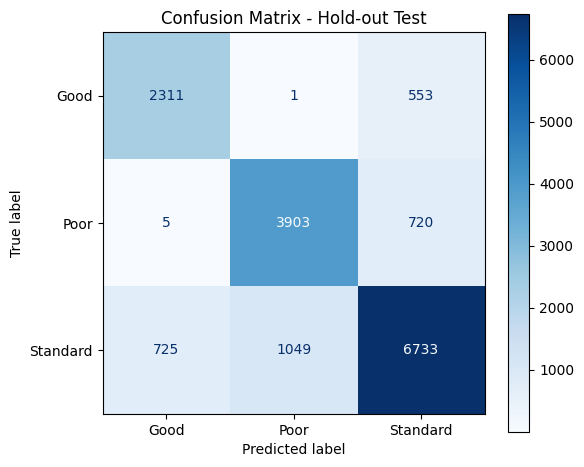

Confusion Matrix Table (Hold-out Test):
                 Pred_Good  Pred_Poor  Pred_Standard
Actual_Good           2311          1            553
Actual_Poor              5       3903            720
Actual_Standard        725       1049           6733


In [ ]:
# ============================================================
# HOLD-OUT TEST F1 (SIMULATED TEST) - IMPROVED VERSION
# ============================================================
dev_df, valid_df = train_test_split(
    train,
    test_size=0.2,
    stratify=train["Credit_Score"],
    random_state=42
)

dev_df = dev_df.copy()
valid_df = valid_df.copy()

dev_df_enriched, _, _ = add_customer_features(dev_df, dev_df)
valid_df_enriched, _, _ = add_customer_features(dev_df, valid_df)

for c in dev_df_enriched.columns:
    if c not in valid_df_enriched.columns:
        valid_df_enriched[c] = np.nan

for c in valid_df_enriched.columns:
    if c not in dev_df_enriched.columns:
        dev_df_enriched[c] = np.nan

valid_df_enriched = valid_df_enriched[dev_df_enriched.columns]

DROP_COLS_HOLDOUT = [
    "ID", "Name", "SSN", "Type_of_Loan", "Credit_Score", "row_signature"
]

FEATURES_HOLDOUT = [
    c for c in dev_df_enriched.columns
    if c not in DROP_COLS_HOLDOUT
]

X_dev = dev_df_enriched[FEATURES_HOLDOUT].copy()
X_valid = valid_df_enriched[FEATURES_HOLDOUT].copy()
y_dev = dev_df_enriched["Credit_Score"].copy()
y_valid = valid_df_enriched["Credit_Score"].copy()

cat_cols_holdout = X_dev.select_dtypes(include=["object"]).columns.tolist()
num_cols_holdout = [c for c in X_dev.columns if c not in cat_cols_holdout]

for c in num_cols_holdout:
    X_dev[c] = pd.to_numeric(X_dev[c], errors="coerce").astype("float32")
    X_valid[c] = pd.to_numeric(X_valid[c], errors="coerce").astype("float32")

preprocessor_holdout = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_holdout),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
        ]), cat_cols_holdout)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

lr_model_holdout = Pipeline([
    ("prep", preprocessor_holdout),
    ("clf", LogisticRegression(
        max_iter=5000,
        C=15.0,
        solver="saga",
        multi_class="multinomial",
        random_state=42
    ))
])

lr_model_holdout.fit(X_dev, y_dev)
valid_lr_pred = pd.Series(lr_model_holdout.predict(X_valid), index=valid_df_enriched.index)

lookup_dev = build_lookup_objects(dev_df_enriched)

final_valid_pred, valid_source = hybrid_predict_frame(
    valid_df_enriched,
    valid_lr_pred,
    lookup_dev
)

holdout_f1 = f1_score(y_valid, final_valid_pred, average="macro")

print("\n===================================")
print(f"HOLD-OUT TEST F1 MACRO: {holdout_f1:.6f}")
print("===================================\n")

print("Classification report (Hold-out Test):")
print(classification_report(y_valid, final_valid_pred))

print("\nPrediction source summary (Hold-out):")
print(valid_source.value_counts())

# ============================================================
# CONFUSION MATRIX - HOLD-OUT TEST (GRAPH)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true=y_valid,
    y_pred=final_valid_pred,
    display_labels=["Good", "Poor", "Standard"],
    cmap="Blues",
    ax=ax
)

ax.set_title("Confusion Matrix - Hold-out Test")
plt.tight_layout()
plt.show()

# ============================================================
# CONFUSION MATRIX - HOLD-OUT TEST (TABLE)
# ============================================================
labels = ["Good", "Poor", "Standard"]

cm = confusion_matrix(y_valid, final_valid_pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{label}" for label in labels],
    columns=[f"Pred_{label}" for label in labels]
)

print("Confusion Matrix Table (Hold-out Test):")
print(cm_df)

## 8. Final Model on Full Training Data

หลังจากประเมินด้วย Hold-out Test แล้ว จะทำการ fit โมเดลบน train set ทั้งหมด เพื่อใช้สร้างผลทำนายจริงสำหรับ `test.csv`


LR Train F1 macro: 0.851324

Classification report (LR on full train):
              precision    recall  f1-score   support

        Good       0.82      0.85      0.83     14322
        Poor       0.83      0.88      0.86     23141
    Standard       0.88      0.84      0.86     42537

    accuracy                           0.86     80000
   macro avg       0.85      0.86      0.85     80000
weighted avg       0.86      0.86      0.86     80000



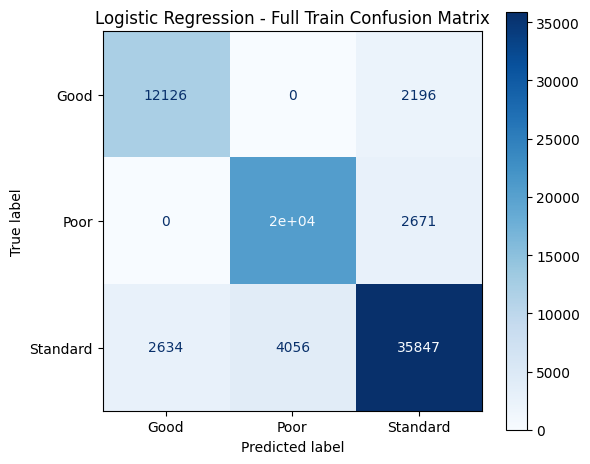

In [ ]:
# ============================================================
# FIT FINAL MODEL ON FULL TRAIN
# ============================================================
lr_model.fit(X_train_df, y)

lr_train_pred = lr_model.predict(X_train_df)

print(f"\nLR Train F1 macro: {f1_score(y, lr_train_pred, average='macro'):.6f}")
print("\nClassification report (LR on full train):")
print(classification_report(y, lr_train_pred))

# ============================================================
# CONFUSION MATRIX ON FULL TRAIN
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true=y,
    y_pred=lr_train_pred,
    display_labels=["Good", "Poor", "Standard"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Logistic Regression - Full Train Confusion Matrix")
plt.tight_layout()
plt.show()

## 9. Final Prediction on Real Test Set

การทำนายจริงบน `test.csv` ใช้ hybrid prediction strategy ตามลำดับความสำคัญของแหล่งทำนาย ได้แก่

1. exact row signature  
2. customer + month  
3. stable customer  
4. dominant customer  
5. month-weighted mode  
6. customer kNN  
7. customer mode  
8. Logistic Regression fallback  

จากนั้นบันทึกผลลงในไฟล์ `result.csv`

In [ ]:
# ============================================================
# FINAL HYBRID PREDICTION ON REAL TEST - IMPROVED VERSION
# ============================================================
lr_test_pred = pd.Series(lr_model.predict(X_test_df), index=test.index)

final_pred, final_source = hybrid_predict_frame(
    test,
    lr_test_pred,
    lookup_full
)

print("\nPrediction source summary (real test):")
print(final_source.value_counts(dropna=False))

print("\nFinal prediction distribution:")
print(final_pred.value_counts(dropna=False))


# ============================================================
# SAVE RESULT
# ============================================================
result = pd.read_csv(test_file)
result["Credit_Score"] = final_pred.values
result.to_csv("result.csv", index=False)

print("\nresult.csv saved ✓")
show_cols = [c for c in ["ID", "Customer_ID", "Credit_Score"] if c in result.columns]
print(result[show_cols].head())

from google.colab import files
files.download("result.csv")

# ============================================================
# CLEAN MEMORY
# ============================================================
gc.collect()
print("Done ✓")


Prediction source summary (real test):
stable_customer        9912
month_weighted_mode    8108
customer_knn           1105
dominant_customer       865
customer_mode            10
Name: count, dtype: int64

Final prediction distribution:
Standard    9933
Poor        6314
Good        3753
Name: count, dtype: int64

result.csv saved ✓
        ID Customer_ID Credit_Score
0  0x2595b  CUS_0x3e03     Standard
1   0xa2e2  CUS_0x3615     Standard
2  0x131cd  CUS_0x9122     Standard
3  0x1bced  CUS_0x3371         Poor
4  0x1ee87   CUS_0xecc         Poor


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done ✓
